# Q1 :


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import joblib
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42


# Q2 :


In [2]:


DATASET = 'iris'  



if DATASET == 'california':
    from sklearn.datasets import fetch_california_housing
    data = fetch_california_housing(as_frame=True)
    X = data.data
    y = data.target
    task_type = 'regression'
    target_name = 'MedHouseVal'
    print('Loaded California Housing (regression).')
elif DATASET == 'iris':
    from sklearn.datasets import load_iris
    data = load_iris(as_frame=True)
    X = data.data
    y = data.target
    task_type = 'classification'
    target_name = 'species'
    print('Loaded Iris (classification).')
else:
    raise ValueError("DATASET must be 'california' or 'iris' ")

print('\nFeatures shape:', X.shape)
print('Target shape:', y.shape)


Loaded Iris (classification).

Features shape: (150, 4)
Target shape: (150,)


# Q3 -Q5 :


In [3]:

print('Missing values per column:')
display(X.isnull().sum())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y if task_type=='classification' else None)
print('\nTrain shape:', X_train.shape, 'Test shape:', X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Missing values per column:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


Train shape: (120, 4) Test shape: (30, 4)


# Q6 - Q7 :


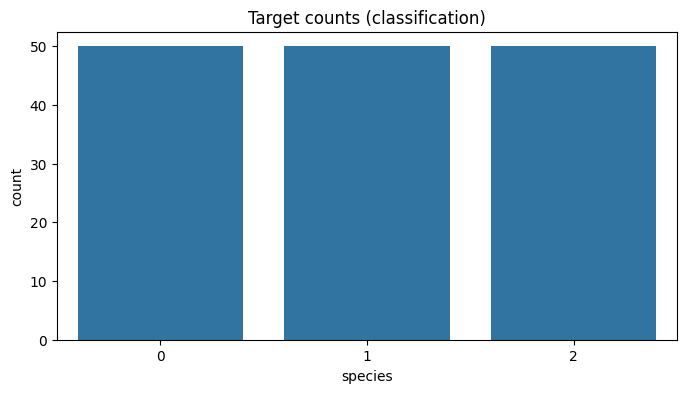

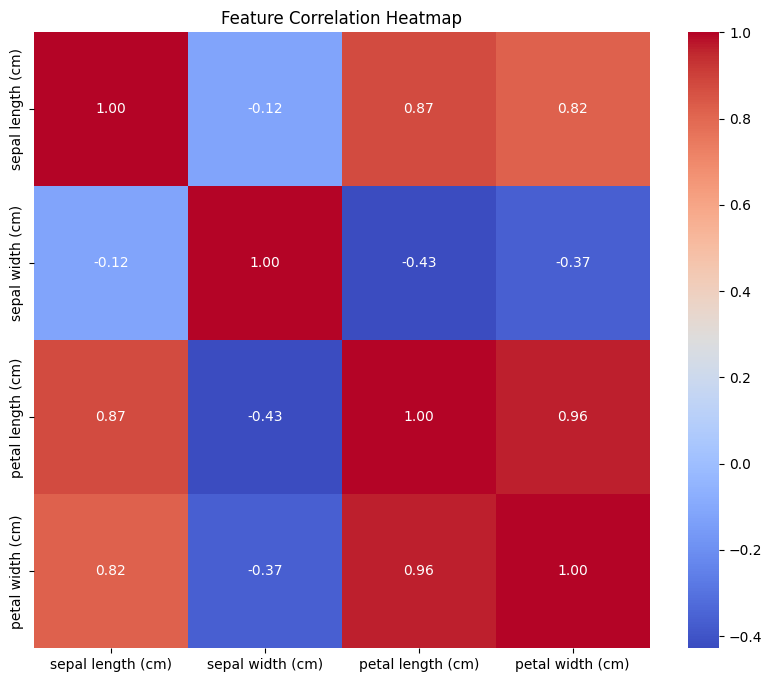

In [4]:

plt.figure(figsize=(8,4))
if task_type == 'regression':
    sns.histplot(y, kde=True)
    plt.title('Target distribution (regression)')
    plt.xlabel(target_name)
else:
    sns.countplot(x=y)
    plt.title('Target counts (classification)')
    plt.xlabel(target_name)
plt.show()


plt.figure(figsize=(10,8))
corr = pd.DataFrame(X).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.show()


# Q8- Q9 :

In [5]:


results = {}

if task_type == 'regression':
    models = {
        'LinearRegression': LinearRegression(),
        'DecisionTree': DecisionTreeRegressor(random_state=RANDOM_STATE),
        'RandomForest': RandomForestRegressor(random_state=RANDOM_STATE),
        'KNN': KNeighborsRegressor(),
        'SVR': SVR()
    }
    Xtr, Xte = X_train_scaled, X_test_scaled
else:
    models = {
        'LogisticRegression': LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
        'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'RandomForest': RandomForestClassifier(random_state=RANDOM_STATE),
        'KNN': KNeighborsClassifier(),
        'SVM': SVC(probability=True, random_state=RANDOM_STATE)
    }
    Xtr, Xte = X_train_scaled, X_test_scaled

for name, model in models.items():
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    results[name] = {
        'model': model,
        'y_pred': y_pred
    }

print('Trained models:', list(models.keys()))


Trained models: ['LogisticRegression', 'DecisionTree', 'RandomForest', 'KNN', 'SVM']


# Q10 -Q11:

In [6]:

eval_df = []

for name, info in results.items():
    y_pred = info['y_pred']
    if task_type == 'regression':
        mse = mean_squared_error(y_test, y_pred)
        rmse = mse ** 0.5
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        eval_df.append({'Model': name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    else:
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        eval_df.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

eval_df = pd.DataFrame(eval_df).set_index('Model')
display(eval_df)

,Accuracy,Precision,Recall,F1
Model,,,,
LogisticRegression,0.933333,0.933333,0.933333,0.933333
DecisionTree,0.933333,0.933333,0.933333,0.933333
RandomForest,0.900000,0.902357,0.900000,0.899749
KNN,0.933333,0.944444,0.933333,0.932660
SVM,0.966667,0.969697,0.966667,0.966583


# Q12:

Confusion matrix for: SVM


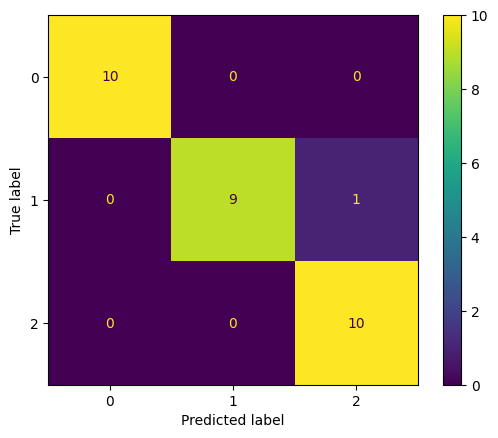

In [7]:
if task_type == 'classification':
    best_name = eval_df['Accuracy'].idxmax() if 'Accuracy' in eval_df.columns else eval_df.index[0]
    best_model = results[best_name]['model']
    y_pred = best_model.predict(Xte)
    print('Confusion matrix for:', best_name)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()
else:
    print('Confusion matrix is only for classification tasks.')


# Q13:

,feature,importance
3,petal width (cm),0.437185
2,petal length (cm),0.431466
0,sepal length (cm),0.116349
1,sepal width (cm),0.015000


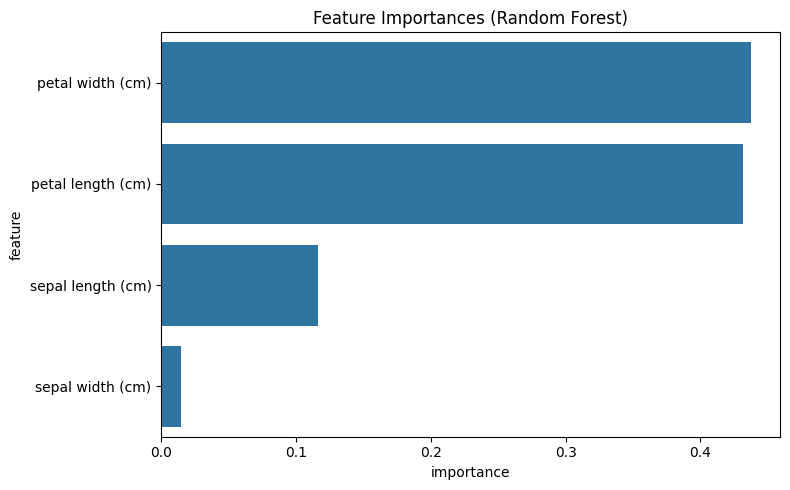

In [8]:
if task_type == 'regression':
    rf = RandomForestRegressor(random_state=RANDOM_STATE)
else:
    rf = RandomForestClassifier(random_state=RANDOM_STATE)
rf.fit(Xtr, y_train)
importances = rf.feature_importances_
feat_names = X.columns if isinstance(X, pd.DataFrame) else [f'F{i}' for i in range(X.shape[1])]

fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances}).sort_values('importance', ascending=False)
display(fi_df)

plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=fi_df)
plt.title('Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

# Q14:

In [12]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
if task_type == 'regression':
    rf_model = RandomForestRegressor(random_state=RANDOM_STATE)
else:
    rf_model = RandomForestClassifier(random_state=RANDOM_STATE)

gscv = GridSearchCV(rf_model, param_grid, cv=3, n_jobs=-1, scoring='r2' if task_type=='regression' else 'accuracy')
gscv.fit(Xtr, y_train)
print('Best params:', gscv.best_params_)
best_rf = gscv.best_estimator_
y_pred_best = best_rf.predict(Xte)


if task_type == 'regression':
    mse = mean_squared_error(y_test, y_pred_best)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_pred_best)
    r2 = r2_score(y_test, y_pred_best)
    print('\nTuned Random Forest metrics:')
    print('MSE:', mse)
    print( 'RMSE:', rmse)
    print( 'MAE:', mae)
    print( 'R2:', r2)

else:
    acc = accuracy_score(y_test, y_pred_best)
    prec = precision_score(y_test, y_pred_best, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred_best, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred_best, average='weighted', zero_division=0)
    print('\nTuned Random Forest metrics:')
    print('Accuracy:', acc)
    print( 'Precision:', prec)
    print( 'Recall:', rec )
    print('F1:', f1)



Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

Tuned Random Forest metrics:
Accuracy: 0.9666666666666667
Precision: 0.9696969696969696
Recall: 0.9666666666666667
F1: 0.9665831244778613


# Q15:

In [10]:

model_filename = 'best_model.pkl'
scaler_filename = 'scaler.pkl'
joblib.dump(best_rf, model_filename)
joblib.dump(scaler, scaler_filename)
print('Saved model to', model_filename)
print('Saved scaler to', scaler_filename)

Saved model to best_model.pkl
Saved scaler to scaler.pkl


# Q16:


In [11]:
reflection = '''
Reflection (edit as needed):
- Model performance: compare eval table above to see which model did best.
- Overfitting: check difference between train and test metrics (not fully shown here — you can compute train metrics similarly).
- Data size: small datasets (like Iris) can cause variance; California dataset size affects model stability.
- Feature scaling: required for distance-based models (KNN, SVR) and improves convergence for models like LogisticRegression / SVM.
- Tuning impact: GridSearch improved RF performance by finding better hyperparameters.
'''
print(reflection)


Reflection (edit as needed):
- Model performance: compare eval table above to see which model did best.
- Overfitting: check difference between train and test metrics (not fully shown here — you can compute train metrics similarly).
- Data size: small datasets (like Iris) can cause variance; California dataset size affects model stability.
- Feature scaling: required for distance-based models (KNN, SVR) and improves convergence for models like LogisticRegression / SVM.
- Tuning impact: GridSearch improved RF performance by finding better hyperparameters.

